# Ejercicio 4 — Reducción de dimensionalidad con PCA

**Objetivo:** reducir las diez variables de `comprar_alquilar.csv` conservando la mayor cantidad posible de información.

**Algoritmo elegido:** Análisis de Componentes Principales (PCA), que transforma variables correlacionadas en componentes ortogonales ordenados por varianza explicada. Se compara PCA sin escalamiento y con estandarización, tal como solicita el ejercicio.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import *
sns.set_theme(style='whitegrid', palette='viridis')
RANDOM_STATE = 42
BASE = Path.cwd()
(BASE/'images').mkdir(exist_ok=True)
(BASE/'models').mkdir(exist_ok=True)

In [2]:
from sklearn.decomposition import PCA
df=pd.read_csv('comprar_alquilar.csv')
display(df.head()); print('Dimensiones:',df.shape); display(df.describe().T); print('Faltantes:',df.isna().sum().sum())
X=df.copy(); labels=df['comprar'].map({0:'Alquilar',1:'Comprar'})

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


Dimensiones: (202, 10)


,count,mean,std,min,25%,50%,75%,max
ingresos,202.0,4958.995050,1682.862556,2008.0,3513.75,4947.5,6374.50,7984.0
gastos_comunes,202.0,971.584158,272.106351,384.0,766.75,968.0,1165.25,1585.0
pago_coche,202.0,211.742574,124.940754,0.0,99.00,208.5,318.75,448.0
gastos_otros,202.0,515.425743,168.103075,201.0,383.25,522.5,656.75,828.0
ahorros,202.0,38749.668317,17365.231870,10319.0,24964.25,38523.0,52150.75,69934.0
vivienda,202.0,373349.638614,136371.525622,176553.0,274810.00,340783.5,444482.00,669540.0
estado_civil,202.0,1.024752,0.837184,0.0,0.00,1.0,2.00,2.0
hijos,202.0,1.232673,1.367833,0.0,0.00,1.0,2.00,4.0
trabajo,202.0,4.490099,2.535794,0.0,2.00,5.0,7.00,8.0
comprar,202.0,0.331683,0.471988,0.0,0.00,0.0,1.00,1.0


Faltantes: 0


## Comparación sin y con escalamiento

Sin escalar, las variables monetarias dominan por sus unidades y magnitudes. Con `StandardScaler`, cada variable aporta desde una escala comparable; esto hace que PCA refleje estructura multivariable y no solamente diferencias de unidades.

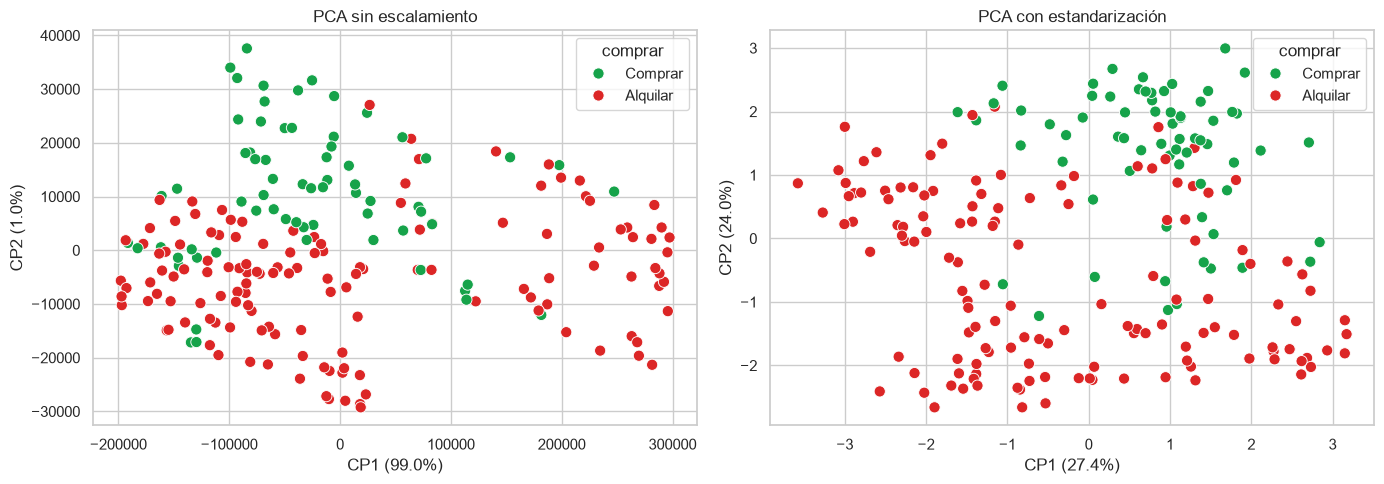

Varianza 2 CP sin escalar: 0.9999
Varianza 2 CP escalado: 0.5133


In [3]:
pca_raw=PCA().fit(X); Zraw=pca_raw.transform(X)
scaler=StandardScaler(); Xs=scaler.fit_transform(X); pca_scaled=PCA().fit(Xs); Zscaled=pca_scaled.transform(Xs)
fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.scatterplot(x=Zraw[:,0],y=Zraw[:,1],hue=labels,palette={'Comprar':'#16a34a','Alquilar':'#dc2626'},s=65,ax=ax[0]); ax[0].set(title='PCA sin escalamiento',xlabel=f'CP1 ({pca_raw.explained_variance_ratio_[0]:.1%})',ylabel=f'CP2 ({pca_raw.explained_variance_ratio_[1]:.1%})')
sns.scatterplot(x=Zscaled[:,0],y=Zscaled[:,1],hue=labels,palette={'Comprar':'#16a34a','Alquilar':'#dc2626'},s=65,ax=ax[1]); ax[1].set(title='PCA con estandarización',xlabel=f'CP1 ({pca_scaled.explained_variance_ratio_[0]:.1%})',ylabel=f'CP2 ({pca_scaled.explained_variance_ratio_[1]:.1%})')
plt.tight_layout(); plt.savefig(BASE/'images'/'comparacion_pca.png',dpi=180); plt.show()
print('Varianza 2 CP sin escalar:',round(pca_raw.explained_variance_ratio_[:2].sum(),4)); print('Varianza 2 CP escalado:',round(pca_scaled.explained_variance_ratio_[:2].sum(),4))

## Elección del número de componentes

Se elige el mínimo número de componentes que conserva al menos 95 % de la varianza acumulada después de estandarizar. Este umbral produce una reducción objetiva con una pérdida máxima aproximada del 5 % de la variabilidad.

Componentes elegidos para ≥95%: 8
Varianza conservada: 0.9651


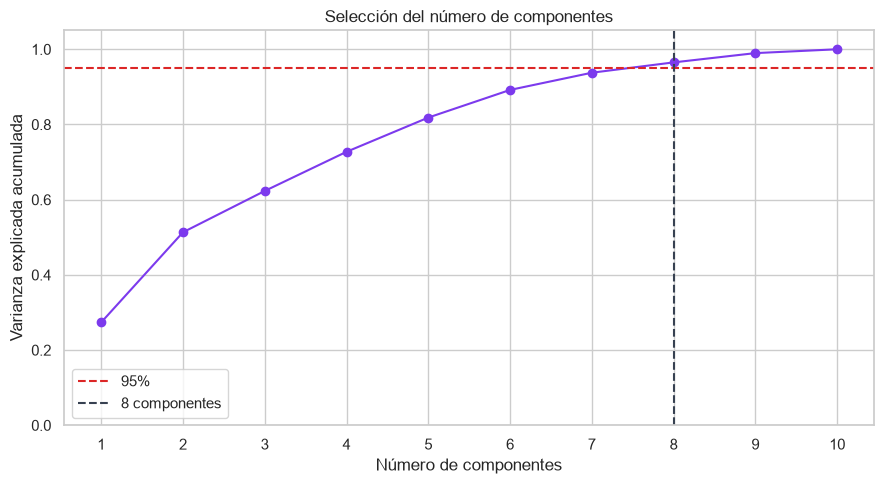

In [4]:
cumulative=np.cumsum(pca_scaled.explained_variance_ratio_); n95=int(np.argmax(cumulative>=.95)+1)
print('Componentes elegidos para ≥95%:',n95); print('Varianza conservada:',round(cumulative[n95-1],4))
plt.figure(figsize=(9,5)); plt.plot(range(1,len(cumulative)+1),cumulative,'o-',color='#7c3aed'); plt.axhline(.95,ls='--',color='#dc2626',label='95%'); plt.axvline(n95,ls='--',color='#374151',label=f'{n95} componentes'); plt.xticks(range(1,len(cumulative)+1)); plt.ylim(0,1.05); plt.xlabel('Número de componentes'); plt.ylabel('Varianza explicada acumulada'); plt.title('Selección del número de componentes'); plt.legend(); plt.tight_layout(); plt.savefig(BASE/'images'/'varianza_acumulada.png',dpi=180); plt.show()

In [5]:
final_pca=PCA(n_components=n95).fit(Xs); X_reduced=final_pca.transform(Xs)
reduced=pd.DataFrame(X_reduced,columns=[f'CP{i+1}' for i in range(n95)]); reduced['comprar_original']=df['comprar']; display(reduced.head())
reduced.to_csv('comprar_alquilar_reducido.csv',index=False)
joblib.dump({'scaler':scaler,'pca':final_pca,'columnas':list(X.columns)},BASE/'models'/'pca_comprar_alquilar.joblib')
loadings=pd.DataFrame(pca_scaled.components_[:2].T,index=X.columns,columns=['CP1','CP2'])
display(loadings.sort_values('CP1',key=abs,ascending=False))

,CP1,CP2,CP3,CP4,CP5,CP6,CP7,CP8,comprar_original
0,1.535449,0.068159,-0.545565,-2.179020,0.355643,-0.348843,-0.510708,-0.878541,1
1,1.282144,0.823909,1.233645,0.081871,-1.201388,0.835942,-1.234253,-0.097668,0
2,0.779890,2.176401,0.438365,-1.265585,1.003528,-0.270164,1.420402,0.876554,1
3,3.150472,-1.288086,-0.290494,-0.190528,-1.351337,1.281028,-0.841160,0.572358,0
4,0.940483,-0.672760,-0.925130,-0.603372,0.491272,-1.490638,0.156435,0.067180,1


,CP1,CP2
ingresos,0.549343,0.159098
ahorros,0.489396,0.135533
vivienda,0.441293,-0.073277
gastos_comunes,0.341460,0.055850
comprar,0.204091,0.396210
trabajo,-0.161600,0.551721
estado_civil,-0.153442,0.453844
pago_coche,-0.150491,-0.076581
hijos,-0.140073,0.524006
gastos_otros,-0.117465,0.005565


## Interpretación de las cargas

Las cargas indican cuánto contribuye cada variable a los primeros componentes. Valores absolutos altos son más influyentes; el signo señala la dirección de la relación.

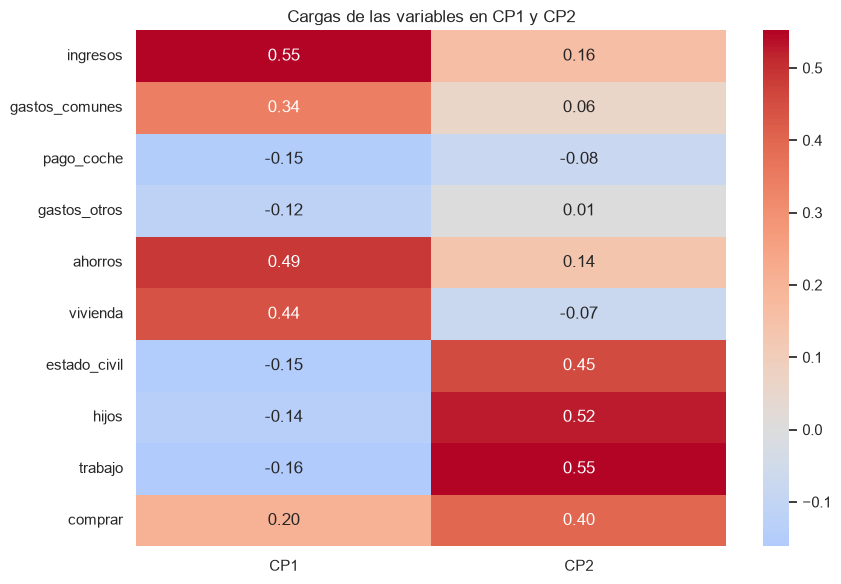

In [6]:
plt.figure(figsize=(9,6)); sns.heatmap(loadings,annot=True,cmap='coolwarm',center=0,fmt='.2f'); plt.title('Cargas de las variables en CP1 y CP2'); plt.tight_layout(); plt.savefig(BASE/'images'/'cargas_pca.png',dpi=180); plt.show()

## Conclusión

La comparación demuestra por qué el escalamiento es necesario: sin él, las variables monetarias concentran casi toda la varianza por sus magnitudes. El modelo final usa datos estandarizados y conserva al menos 95 % de la varianza con el menor número posible de componentes. Los dos primeros se usan para visualización; el número final puede ser mayor porque la visualización y la conservación de información son objetivos distintos.